### Домашнее задание: Классификация дорожных знаков

Создаю свой классификатор дорожных знаков.

In [1]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 6]

## Шаг 1: Загрузка данных и визуализация

Загружаю данные из папки `subset_homework` и смотрю, как выглядят примеры. Также считаю, сколько изображений в каждом классе.

Class 0: 2220 images


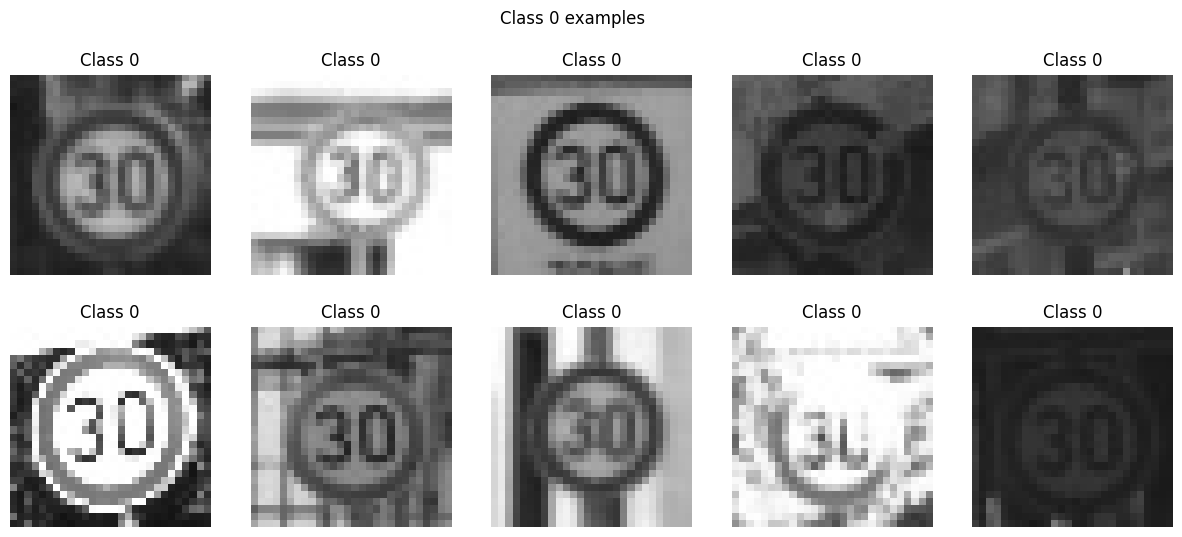

In [2]:
folder = 'subset_homework'

# Load class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

print(f'Class 0: {len(images_0)} images')

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Class 0'), plt.axis(False)
plt.suptitle('Class 0 examples')
plt.show()

Class 1: 2250 images


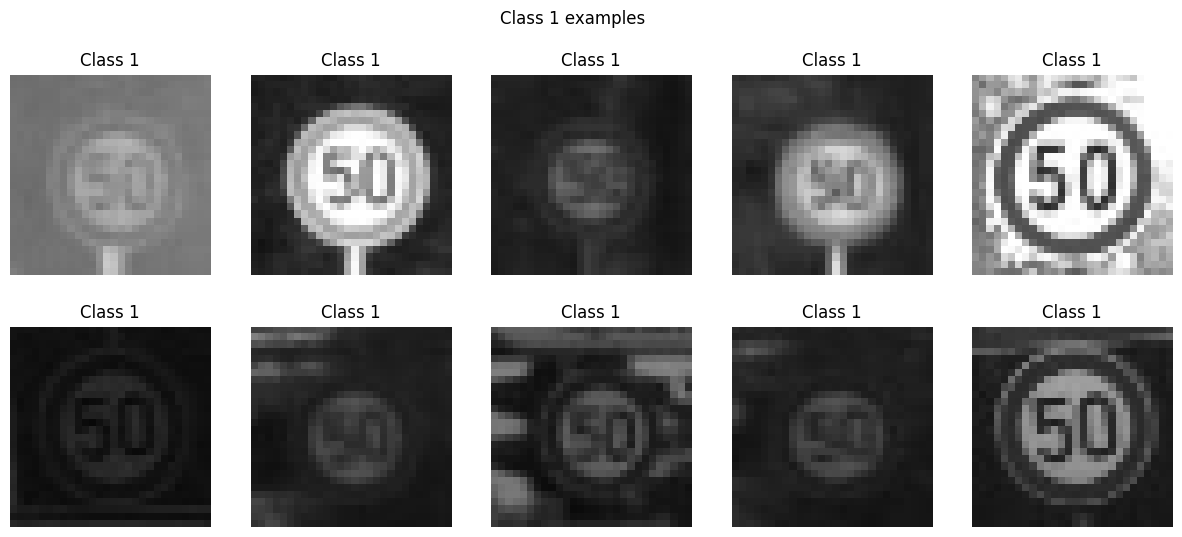

In [3]:
# Load class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

print(f'Class 1: {len(images_1)} images')

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Class 1'), plt.axis(False)
plt.suptitle('Class 1 examples')
plt.show()

In [4]:
print(f'Number of images in class 0: {len(images_0)}')
print(f'Number of images in class 1: {len(images_1)}')
print(f'Total: {len(images_0) + len(images_1)}')

Number of images in class 0: 2220
Number of images in class 1: 2250
Total: 4470


## Подготовка данных

Объединяю оба класса, перемешиваю, разворачиваю изображения в одномерные векторы и делю на train/test.

In [5]:
# Combine and shuffle
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels, random_state=42)

images = np.array(images)
labels = np.array(labels)

print('Images shape:', images.shape)
print('Labels shape:', labels.shape)

Images shape: (4470, 28, 28)
Labels shape: (4470,)


In [6]:
# Flatten and normalize to [0, 1]
pixels = np.array([image.flatten() for image in images]) / 255.0
print('Pixels shape:', pixels.shape)

Pixels shape: (4470, 784)


In [7]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(pixels, labels, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 3576 samples
Test:  894 samples


## Шаг 2: Классификатор с одним нейроном

Обучаю модель с одним нейроном.

In [8]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

In [9]:
# Single neuron model (like in the lecture)
inputs = Input(shape=(X_train.shape[1],))
outputs = Dense(1, activation='linear')(inputs)
model_single = Model(inputs, outputs)

model_single.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_single.compile(optimizer='adam', loss='mean_squared_error')
history_single = model_single.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 0.3426 - val_loss: 0.2712
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - loss: 0.2484 - val_loss: 0.2283
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step - loss: 0.2127 - val_loss: 0.1869
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.1815 - val_loss: 0.1754
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - loss: 0.1585 - val_loss: 0.1520
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.1455 - val_loss: 0.1436
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - loss: 0.1353 - val_loss: 0.1275
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step - loss: 0.1231 - val_loss: 0.1301
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - loss: 0.1154 - val_loss: 0.1245
Epoch 10/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - loss: 0.1116 - val_loss: 0.1127


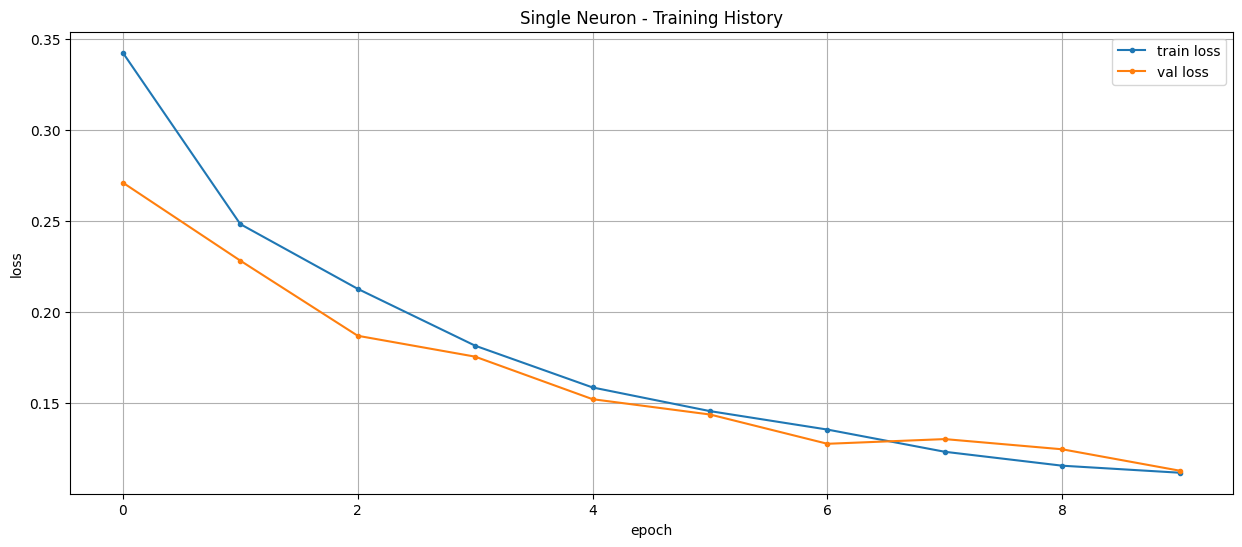

In [11]:
# Plot training history
h = history_single.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-', label='train loss')
plt.plot(epochs, h['val_loss'], '.-', label='val loss')
plt.grid(True), plt.legend()
plt.xlabel('epoch'), plt.ylabel('loss')
plt.title('Single Neuron - Training History')
plt.show()

In [12]:
# Evaluate on train set
train_preds = (model_single.predict(X_train).squeeze() > 0.5).astype(int)
train_acc = np.mean(train_preds == y_train)

# Evaluate on test set
test_preds = (model_single.predict(X_test).squeeze() > 0.5).astype(int)
test_acc = np.mean(test_preds == y_test)

print(f'Single neuron - Train accuracy: {train_acc:.4f}')
print(f'Single neuron - Test accuracy:  {test_acc:.4f}')

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step
Single neuron - Train accuracy: 0.8921
Single neuron - Test accuracy:  0.8881


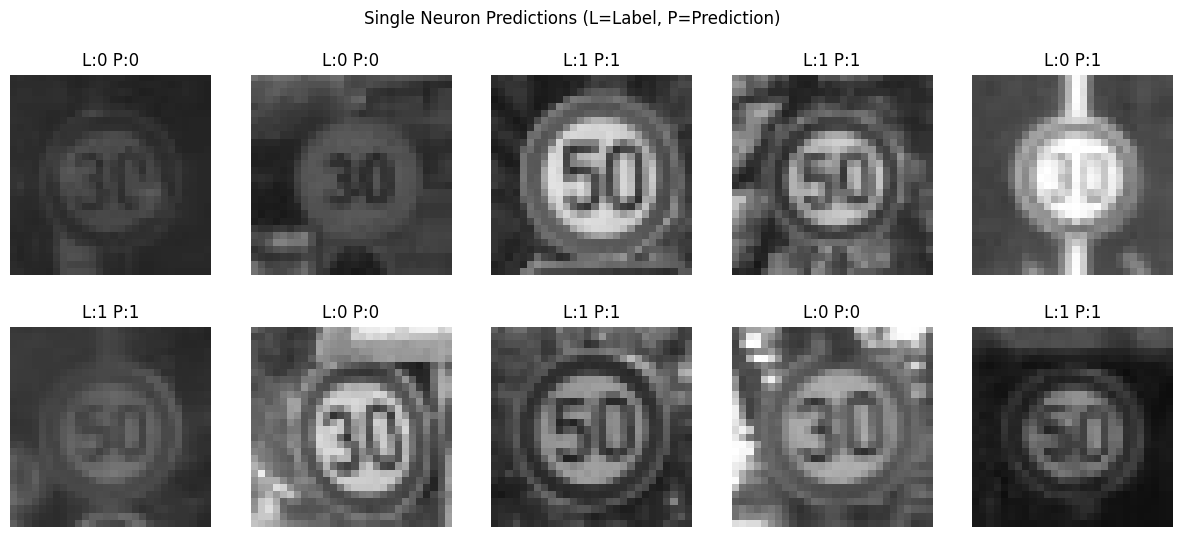

In [13]:
# Visualize some predictions
for cnt, idx in enumerate(np.random.randint(0, len(X_test), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(X_test[idx].reshape(images[0].shape), cmap='gray', vmin=0, vmax=1)
    plt.title(f'L:{y_test[idx]} P:{test_preds[idx]}')
    plt.axis(False)
plt.suptitle('Single Neuron Predictions (L=Label, P=Prediction)')
plt.show()

## Шаг 3: Улучшение модели

Добавляю больше нейронов и слоёв, чтобы повысить точность.

In [14]:
# Model with multiple layers
inputs = Input(shape=(X_train.shape[1],))
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model_improved = Model(inputs, outputs)

model_improved.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_improved.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_improved = model_improved.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6521 - loss: 0.6238 - val_accuracy: 0.7774 - val_loss: 0.5192
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - accuracy: 0.7872 - loss: 0.4822 - val_accuracy: 0.7886 - val_loss: 0.4304
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - accuracy: 0.8803 - loss: 0.3446 - val_accuracy: 0.8512 - val_loss: 0.3757
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.8935 - loss: 0.2941 - val_accuracy: 0.9340 - val_loss: 0.2219
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.9262 - loss: 0.2221 - val_accuracy: 0.9038 - val_loss: 0.2394
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.9270 - loss: 0.2080 - val_accuracy: 0.9206 - val_loss: 0.2121
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.9309 - loss: 0.2009 - val_accuracy: 0.9463 - val_loss: 0.1587
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.9362 - loss: 0.1880 - va

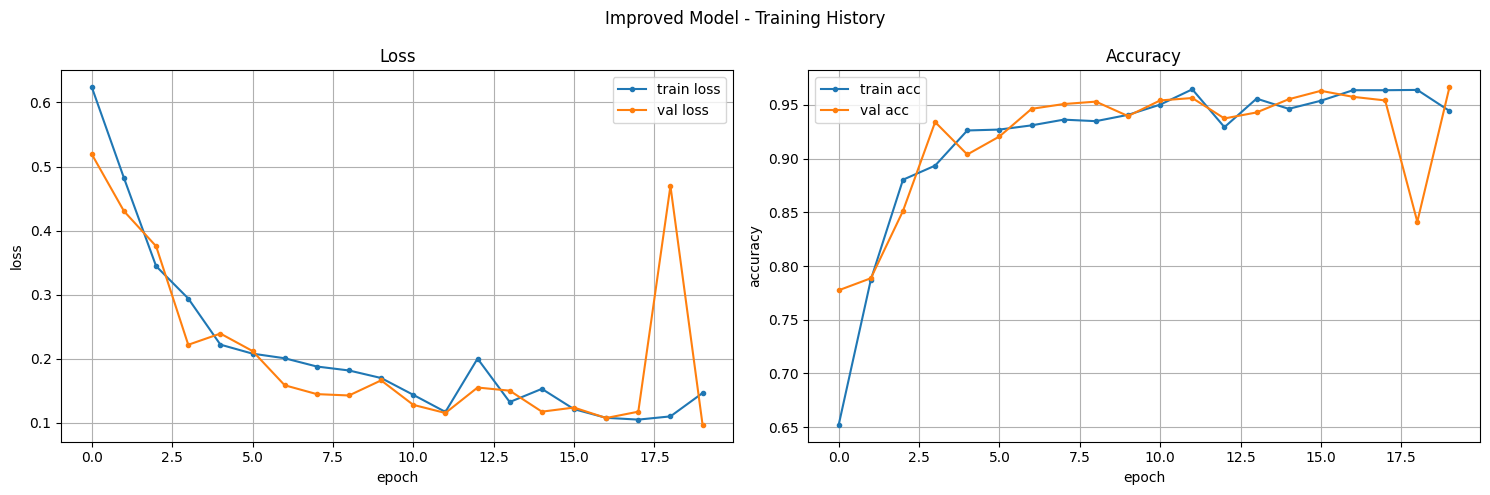

In [16]:
# Plot training history
h = history_improved.history
epochs = range(len(h['loss']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, h['loss'], '.-', label='train loss')
ax1.plot(epochs, h['val_loss'], '.-', label='val loss')
ax1.set_xlabel('epoch'), ax1.set_ylabel('loss')
ax1.legend(), ax1.grid(True)
ax1.set_title('Loss')

ax2.plot(epochs, h['accuracy'], '.-', label='train acc')
ax2.plot(epochs, h['val_accuracy'], '.-', label='val acc')
ax2.set_xlabel('epoch'), ax2.set_ylabel('accuracy')
ax2.legend(), ax2.grid(True)
ax2.set_title('Accuracy')

plt.suptitle('Improved Model - Training History')
plt.tight_layout()
plt.show()

In [17]:
# Evaluate improved model
train_preds_imp = (model_improved.predict(X_train).squeeze() > 0.5).astype(int)
train_acc_imp = np.mean(train_preds_imp == y_train)

test_preds_imp = (model_improved.predict(X_test).squeeze() > 0.5).astype(int)
test_acc_imp = np.mean(test_preds_imp == y_test)

print(f'Improved model - Train accuracy: {train_acc_imp:.4f}')
print(f'Improved model - Test accuracy:  {test_acc_imp:.4f}')

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step
Improved model - Train accuracy: 0.9829
Improved model - Test accuracy:  0.9664


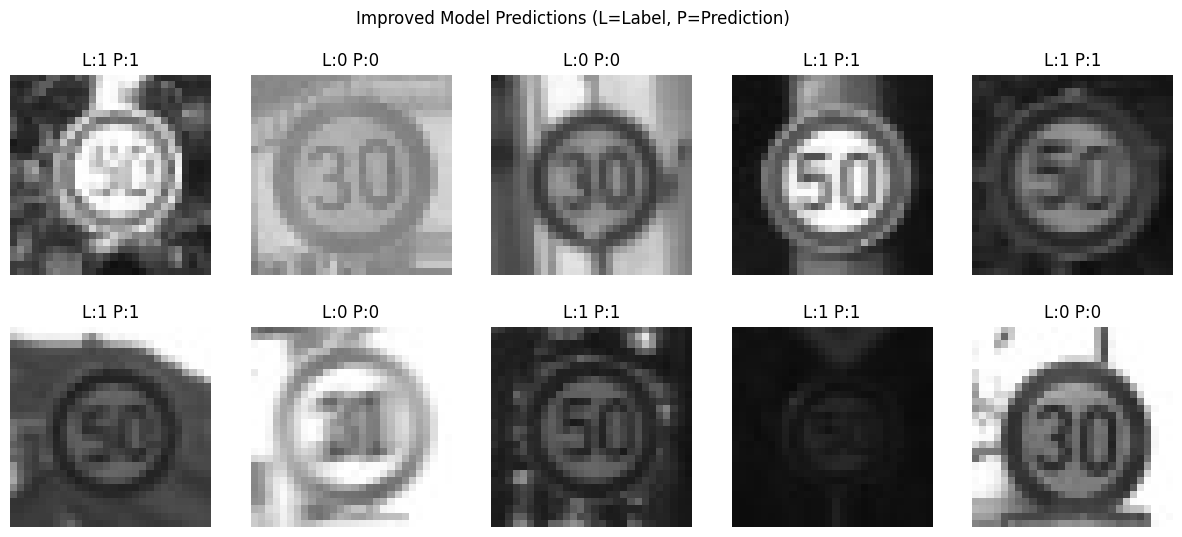

In [18]:
# Visualize some predictions from improved model
for cnt, idx in enumerate(np.random.randint(0, len(X_test), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(X_test[idx].reshape(images[0].shape), cmap='gray', vmin=0, vmax=1)
    plt.title(f'L:{y_test[idx]} P:{test_preds_imp[idx]}')
    plt.axis(False)
plt.suptitle('Improved Model Predictions (L=Label, P=Prediction)')
plt.show()

## Сравнение результатов

In [19]:
print('=== Results ===')
print(f'Single neuron  - Test accuracy: {test_acc:.4f}')
print(f'Improved model - Test accuracy: {test_acc_imp:.4f}')

=== Results ===
Single neuron  - Test accuracy: 0.8881
Improved model - Test accuracy: 0.9664


## Выводы

1. **Датасет** содержит 4470 изображений дорожных знаков двух классов (2220 и 2250 соответственно). Классы сбалансированы, что хорошо для обучения.

2. **Один нейрон** (линейная модель с MSE loss) показал accuracy **~88.8%** на тесте. Это неплохой результат для такой простой модели — значит, классы достаточно хорошо разделимы даже линейно.

3. **Улучшенная модель** с двумя скрытыми слоями (128 и 64 нейрона, ReLU активация, sigmoid на выходе, binary crossentropy loss) достигла accuracy **~96.6%** на тесте. Добавление нелинейных слоёв позволило модели лучше уловить различия между классами и повысить точность почти на 8 процентных пунктов.